In [26]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import os
import json
import joblib

In [2]:
# Chargement du dataset Iris
iris = load_iris()

# Séparation entre les features et la target
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Nombre d'observations :", X.shape[0])
print("Nombre de variables :", X.shape[1])
print("Classes :", target_names)

Nombre d'observations : 150
Nombre de variables : 4
Classes : ['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map(dict(enumerate(target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
df.shape

(150, 6)

## Exploration des données

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## Nettoyage des données

In [8]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [9]:
# Vérification des doublons
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 1


In [10]:
# Nettoyage des doublons
df = df.drop_duplicates()
print("Nombre d'observations après nettoyage :", len(df))
print("Nombre de doublons :", df.duplicated().sum())

Nombre d'observations après nettoyage : 149
Nombre de doublons : 0


In [11]:
# Vérification des classes
print("Classes présentes :", df["target"].unique())
print("Nombre de classes :", df["target"].nunique())

Classes présentes : [0 1 2]
Nombre de classes : 3


In [12]:
# vérification des valeurs numériques
print("Valeurs négatives :")
print((df[feature_names] < 0).sum())

Valeurs négatives :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


## Préparation des données

In [13]:
# séparation des données (features, target)
X = df[feature_names]
y = df["target"]

In [14]:
# Séparation split / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Données d'entraînement :", X_train.shape)
print("Données de test :", X_test.shape)

Données d'entraînement : (119, 4)
Données de test : (30, 4)


## Entrainement du modèle

In [15]:
# Modèle à entrainé
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [16]:
# Entrainement du modèle
model.fit(X_train, y_train)

print("Entraînement terminé.")

Entraînement terminé.


In [17]:
# Prédictions avec les données de test
y_pred = model.predict(X_test)

print("Prédictions :")
print(y_pred)

Prédictions :
[1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 2 0 2 0 1 1 0 0 1 1 2 2 2 1]


In [18]:
# comparaison des prédictions avec le réel
results = pd.DataFrame({
    "Réel": y_test.values,
    "Prédit": y_pred
})

results.head(10)

,Réel,Prédit
0,1,1
1,1,1
2,2,2
3,0,0
4,2,2
5,1,1
6,1,1
7,0,0
8,2,2
9,2,2


# Evaluation du modèle

In [19]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9333


In [20]:
# precision, recall, f1-score
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



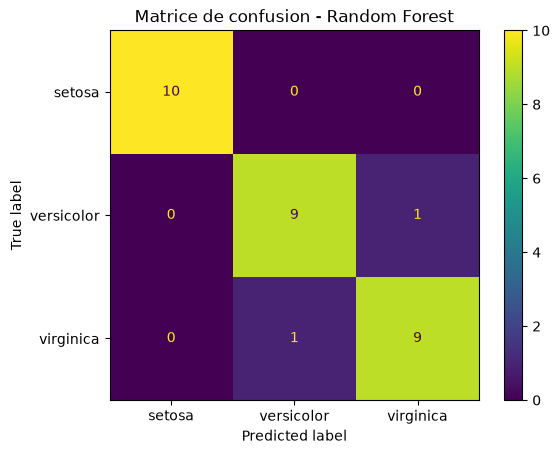

In [21]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()

plt.title("Matrice de confusion - Random Forest")
plt.show()

## Validation du modèle

In [22]:
# Critère d'acceptation
MIN_ACCURACY = 0.90

if accuracy >= MIN_ACCURACY:
    print(f"Modèle validé : accuracy = {accuracy:.4f}")
else:
    print(f"Modèle rejeté : accuracy = {accuracy:.4f}")

Modèle validé : accuracy = 0.9333


In [ ]:
# enregistrement du modèle d'iris si l'accuracy est > 0,90
model_path = "../models/iris_model.joblib"

if accuracy >= MIN_ACCURACY:
    joblib.dump(model, model_path)
    print(f"Modèle enregistré dans : {model_path}")
else:
    print("Le modèle n'est pas enregistré car ses performances sont insuffisantes.")

Modèle enregistré dans : ../models/iris_model.joblib


## Enregistrement des métriques du modèle

In [27]:
# enregistrement des métriques du modèles récents dans un fichier json
metrics = {
    "model": "RandomForestClassifier",
    "accuracy": float(accuracy),
    "n_estimators": 100,
    "random_state": 42,
    "test_size": 0.20
}

metrics_path = "../models/metrics.json"

if accuracy >= MIN_ACCURACY:
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)

    print(f"Métriques enregistrées dans : {metrics_path}")

Métriques enregistrées dans : ../models/metrics.json
